In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

In [ ]:

df = pd.read_csv('Employee-Attrition.csv')
print("Dataset shape:", df.shape)
print("Rows:", df.shape[0], "| Columns:", df.shape[1])

Dataset shape: (1470, 35)
Rows: 1470 | Columns: 35


In [ ]:
df.head()
print("Column names:\n", df.columns.tolist())
df.info()
df.describe()

Column names:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-nul

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
missing = df.isnull().sum()
print("Missing values:\n", missing[missing > 0])
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 Series([], dtype: int64)

Duplicate rows: 0


Attrition count:
 Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition percentage:
 Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


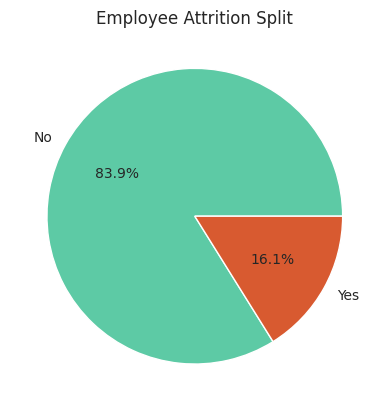

In [ ]:
print("Attrition count:\n", df['Attrition'].value_counts())
print()
print("Attrition percentage:\n",
      df['Attrition'].value_counts(normalize=True).mul(100).round(1))

df['Attrition'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                        colors=['#5DCAA5', '#D85A30'],
                                        title='Employee Attrition Split')
plt.ylabel('')
plt.show()

In [ ]:
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(columns=cols_to_drop)

print("Columns after dropping:", df.shape[1])
print("Remaining columns:\n", df.columns.tolist())

Columns after dropping: 31
Remaining columns:
 ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):\n", numeric_cols)
print()
print(f"Categorical columns ({len(cat_cols)}):\n", cat_cols)

df.to_csv('hr_attrition_clean.csv', index=False)
print("\nClean dataset saved as hr_attrition_clean.csv")

Numeric columns (23):
 ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (8):
 ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Clean dataset saved as hr_attrition_clean.csv


/tmp/ipykernel_3306/1371369325.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=dept, x='Department', y='Attrition_Count',


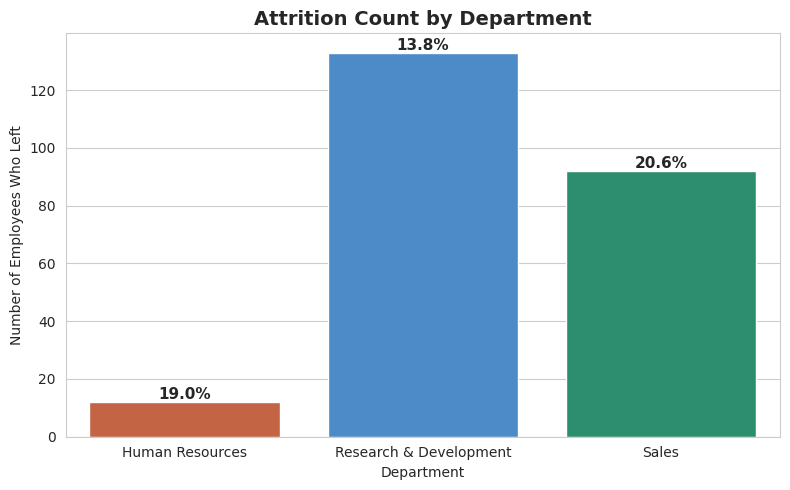

In [ ]:
dept = df[df['Attrition'] == 'Yes'].groupby('Department').size().reset_index()
dept.columns = ['Department', 'Attrition_Count']

total = df.groupby('Department').size().reset_index()
total.columns = ['Department', 'Total']
dept = dept.merge(total, on='Department')
dept['Rate_%'] = (dept['Attrition_Count'] / dept['Total'] * 100).round(1)

plt.figure(figsize=(8, 5))
bars = sns.barplot(data=dept, x='Department', y='Attrition_Count',
                    palette=['#D85A30', '#378ADD', '#1D9E75'])

for i, row in dept.iterrows():
    bars.text(i, row['Attrition_Count'] + 1,
             f"{row['Rate_%']}%", ha='center', fontsize=11, fontweight='bold')

plt.title('Attrition Count by Department', fontsize=14, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Number of Employees Who Left')
plt.tight_layout()
plt.show()

Overtime workers who left:    127/416 = 30.5%
Non-overtime workers who left: 110/1054  = 10.4%


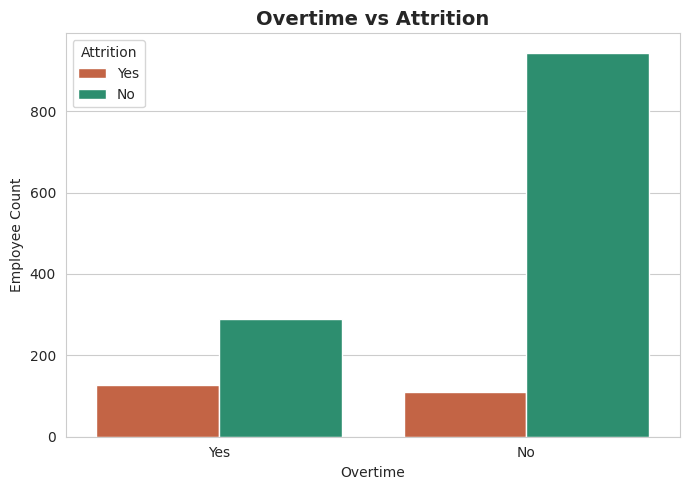

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='OverTime', hue='Attrition',
              palette={'Yes': '#D85A30', 'No': '#1D9E75'})

ot_yes_left = len(df[(df['OverTime']=='Yes') & (df['Attrition']=='Yes')])
ot_yes_tot  = len(df[df['OverTime']=='Yes'])
ot_no_left  = len(df[(df['OverTime']=='No')  & (df['Attrition']=='Yes')])
ot_no_tot   = len(df[df['OverTime']=='No'])

print(f"Overtime workers who left:    {ot_yes_left}/{ot_yes_tot} = {ot_yes_left/ot_yes_tot*100:.1f}%")
print(f"Non-overtime workers who left: {ot_no_left}/{ot_no_tot}  = {ot_no_left/ot_no_tot*100:.1f}%")

plt.title('Overtime vs Attrition', fontsize=14, fontweight='bold')
plt.xlabel('Overtime')
plt.ylabel('Employee Count')
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

Median salary — Left:   $3,202
Median salary — Stayed: $5,204


/tmp/ipykernel_3306/3367109258.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',


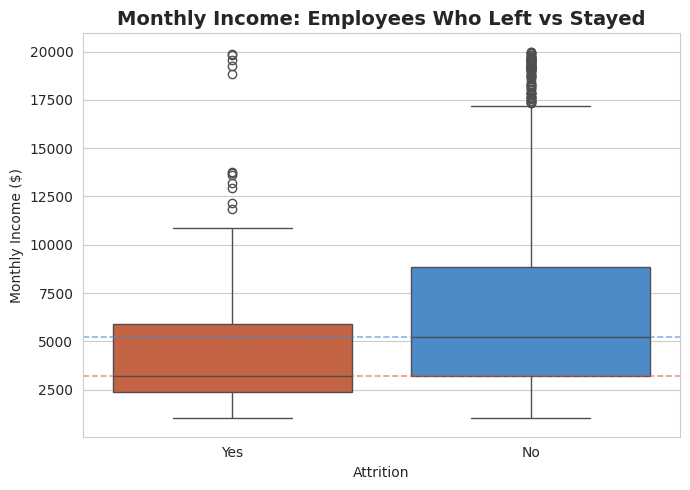

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
             palette={'Yes': '#D85A30', 'No': '#378ADD'})

med_left   = df[df['Attrition']=='Yes']['MonthlyIncome'].median()
med_stayed = df[df['Attrition']=='No'] ['MonthlyIncome'].median()
print(f"Median salary — Left:   ${med_left:,.0f}")
print(f"Median salary — Stayed: ${med_stayed:,.0f}")

plt.axhline(med_left,   color='#D85A30', linestyle='--', alpha=0.6, linewidth=1.2)
plt.axhline(med_stayed, color='#378ADD', linestyle='--', alpha=0.6, linewidth=1.2)

plt.title('Monthly Income: Employees Who Left vs Stayed', fontsize=14, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income ($)')
plt.tight_layout()
plt.show()

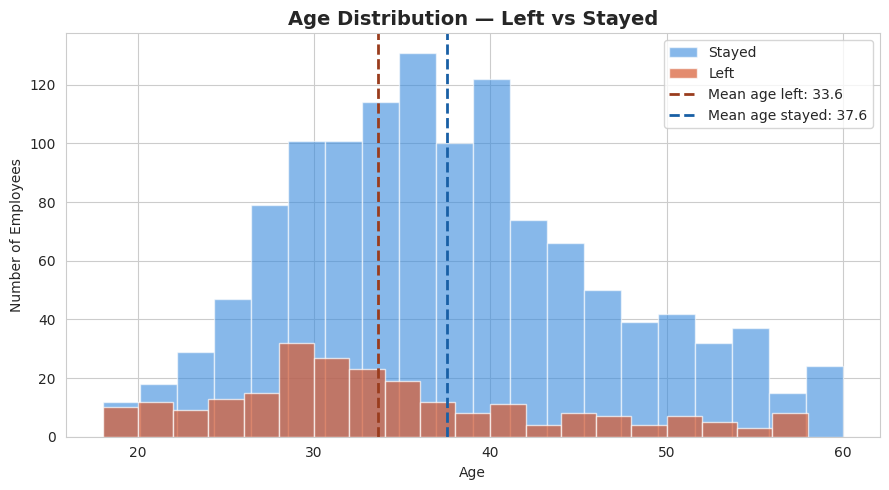

In [ ]:
age_left   = df[df['Attrition']=='Yes']['Age']
age_stayed = df[df['Attrition']=='No'] ['Age']

plt.figure(figsize=(9, 5))

plt.hist(age_stayed, bins=20, alpha=0.6, color='#378ADD', label='Stayed', edgecolor='white')
plt.hist(age_left,   bins=20, alpha=0.7, color='#D85A30', label='Left',   edgecolor='white')

plt.axvline(age_left.mean(),   color='#993C1D', linestyle='--', linewidth=2,
            label=f'Mean age left: {age_left.mean():.1f}')
plt.axvline(age_stayed.mean(), color='#185FA5', linestyle='--', linewidth=2,
            label=f'Mean age stayed: {age_stayed.mean():.1f}')

plt.title('Age Distribution — Left vs Stayed', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Number of Employees')
plt.legend()
plt.tight_layout()
plt.show()

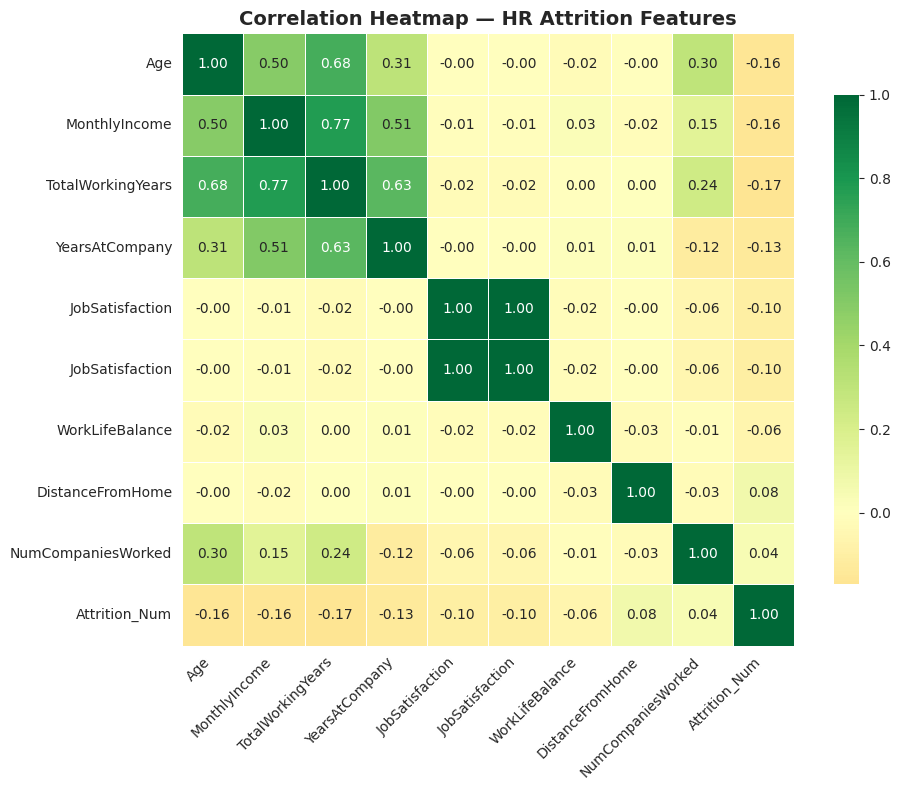


Top factors correlated with Attrition:
TotalWorkingYears    0.171063
MonthlyIncome        0.159840
Age                  0.159205
YearsAtCompany       0.134392
JobSatisfaction      0.103481
Name: Attrition_Num, dtype: float64


In [ ]:
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})
num_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
            'OverTime_Num' if 'OverTime_Num' in df.columns else 'JobSatisfaction',
            'JobSatisfaction', 'WorkLifeBalance', 'DistanceFromHome',
            'NumCompaniesWorked', 'Attrition_Num']

num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap — HR Attrition Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("\nTop factors correlated with Attrition:")
print(corr['Attrition_Num'].drop('Attrition_Num').abs().sort_values(ascending=False).head(5))

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                               confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("All ML libraries imported!")

All ML libraries imported!


In [ ]:
df_ml = df.copy()
text_cols = df_ml.select_dtypes(include=['object']).columns.tolist()
print("Text columns to encode:", text_cols)

le = LabelEncoder()
for col in text_cols:
    df_ml[col] = le.fit_transform(df_ml[col])
    print(f"  Encoded: {col}")

print("\nAll columns are now numeric!")
df_ml.head(3)

Text columns to encode: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
  Encoded: Attrition
  Encoded: BusinessTravel
  Encoded: Department
  Encoded: EducationField
  Encoded: Gender
  Encoded: JobRole
  Encoded: MaritalStatus
  Encoded: OverTime

All columns are now numeric!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Num
0,41,1,2,1102,2,1,2,1,2,0,...,1,0,8,0,1,6,4,0,5,1
1,49,0,1,279,1,8,1,1,3,1,...,4,1,10,3,3,10,7,1,7,0
2,37,1,2,1373,1,2,2,4,4,1,...,2,0,7,3,3,0,0,0,0,1


In [ ]:
y = df_ml['Attrition']

cols_to_drop = ['Attrition']

if 'Attrition_Num' in df_ml.columns:
    cols_to_drop.append('Attrition_Num')
    print("Attrition_Num found and removed — this was causing 100% accuracy!")

X = df_ml.drop(columns=cols_to_drop)

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target  (y) shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

leak_cols = [c for c in X.columns if 'attrition' in c.lower()]
if leak_cols:
    print(f"\nWARNING — still found: {leak_cols} — drop these too!")
else:
    print("\nNo leakage columns found. X is clean!")

Attrition_Num found and removed — this was causing 100% accuracy!

Features (X) shape: (1470, 30)
Target  (y) shape: (1470,)

Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64

No leakage columns found. X is clean!


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing  set size: {X_test.shape[0]} rows")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learn scale from train only
X_test_scaled  = scaler.transform(X_test)       # apply same scale to test

print("\nFeatures scaled successfully!")

Training set size: 1176 rows
Testing  set size: 294 rows

Features scaled successfully!


In [ ]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc*100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Stayed (0)', 'Left (1)']))

Model Accuracy: 75.17%

Detailed Classification Report:
              precision    recall  f1-score   support

  Stayed (0)       0.94      0.75      0.84       247
    Left (1)       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294



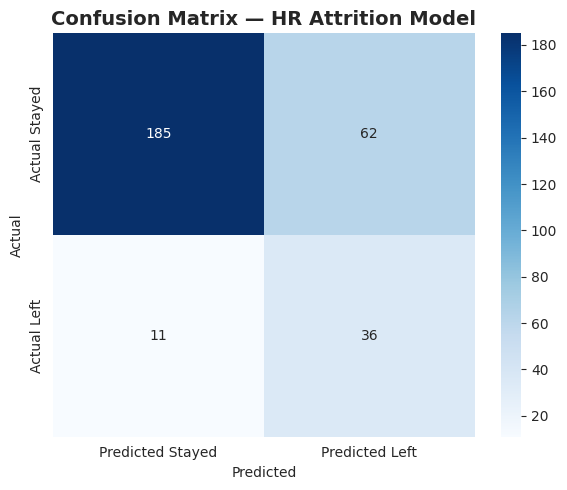


Correctly predicted STAYED: 185
Correctly predicted LEFT:   36
Wrong — said stayed but left: 11
Wrong — said left but stayed: 62


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed', 'Predicted Left'],
            yticklabels=['Actual Stayed',    'Actual Left'])

plt.title('Confusion Matrix — HR Attrition Model', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nCorrectly predicted STAYED: {tn}")
print(f"Correctly predicted LEFT:   {tp}")
print(f"Wrong — said stayed but left: {fn}")
print(f"Wrong — said left but stayed: {fp}")

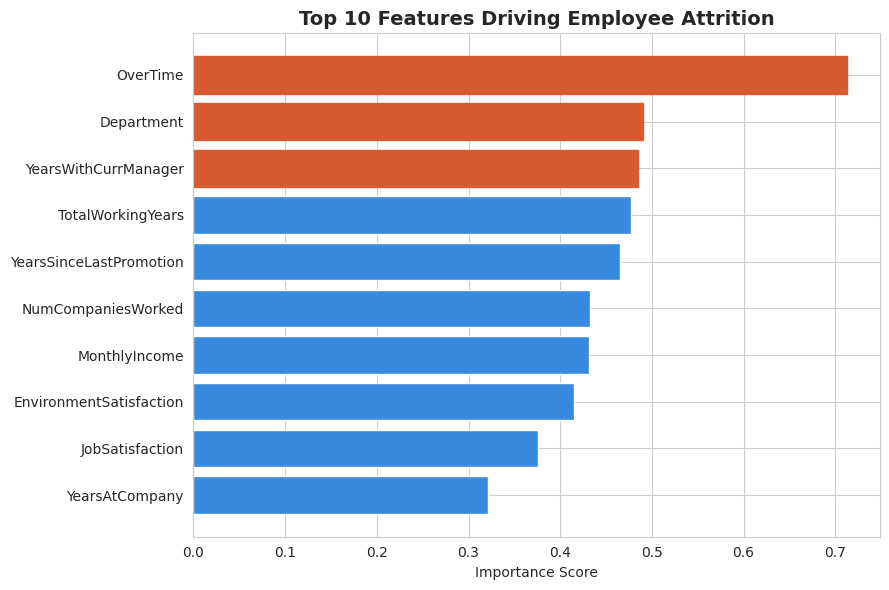


Top 10 factors causing attrition:
                Feature  Importance
               OverTime    0.713114
             Department    0.490580
   YearsWithCurrManager    0.484376
      TotalWorkingYears    0.477399
YearsSinceLastPromotion    0.465691
     NumCompaniesWorked    0.431994
          MonthlyIncome    0.430919
EnvironmentSatisfaction    0.415511
        JobSatisfaction    0.375449
         YearsAtCompany    0.320837


In [ ]:
importance = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': np.abs(model.coef_[0])
})

importance = importance.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(9, 6))
bars = plt.barh(importance['Feature'], importance['Importance'],
               color='#378ADD', edgecolor='white')
for i, bar in enumerate(bars):
    if i < 3:
        bar.set_color('#D85A30')

plt.xlabel('Importance Score')
plt.title('Top 10 Features Driving Employee Attrition',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 factors causing attrition:")
print(importance.to_string(index=False))

In [ ]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

results_df = X_test.copy()
results_df['Actual_Attrition']    = y_test.values
results_df['Predicted_Attrition'] = y_pred
results_df['Leave_Probability']   = y_prob.round(2)

results_df.to_csv('hr_model_results.csv', index=False)
print("Model results saved as hr_model_results.csv")
print(f"File has {len(results_df)} rows with predictions + probability scores")
print("\nPhase 3 complete! Ready for Power BI dashboard.")

Model results saved as hr_model_results.csv
File has 294 rows with predictions + probability scores

Phase 3 complete! Ready for Power BI dashboard.
